# Interactive Sales Dashboard
### Week 6 Project — Data Visualization Mastery with Seaborn & Plotly

This notebook builds a full visualization suite from `sales_data.csv`:
statistical plots with Seaborn (box, violin, heatmaps), a 2x2 static
dashboard, and three interactive Plotly charts (hover, dropdown, animation),
combined into `dashboard.html`.

Shared data prep, color palette, and the Plotly HTML renderer live in
`data_utils.py` so this notebook and `dashboard.py` never drift apart.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display

from data_utils import (
    load_and_prepare, REGION_COLORS, PRODUCT_COLORS, SEABORN_PALETTE,
    plotly_fragment_html, PLOTLY_AVAILABLE,
)

sns.set_theme(style='whitegrid', palette=SEABORN_PALETTE)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

print("Plotly package available:", PLOTLY_AVAILABLE)
print("Libraries loaded.")

Plotly package available: False
Libraries loaded.


## Day 1: Seaborn Basics

Load the data and take a first pass with a simple, styled chart before
moving to the more advanced statistical plots.

In [2]:
df = load_and_prepare('sales_data.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (100, 9)
        Date     Product  Quantity  ...  Total_Sales    Month MonthLabel
0 2024-01-01       Phone         7  ...       261100  2024-01   Jan 2024
1 2024-01-02  Headphones         4  ...        61624  2024-01   Jan 2024
2 2024-01-03       Phone         2  ...        43492  2024-01   Jan 2024
3 2024-01-04  Headphones         1  ...        30895  2024-01   Jan 2024
4 2024-01-05      Laptop         8  ...       318680  2024-01   Jan 2024

[5 rows x 9 columns]


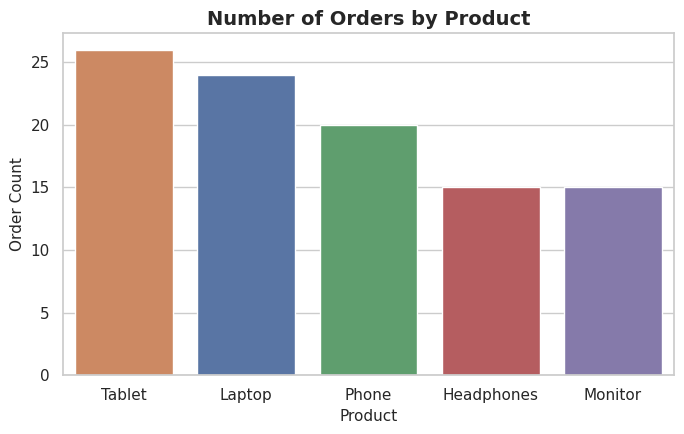

In [3]:
# A basic Seaborn plot with a custom palette and theme, before we get to
# box/violin plots — order counts by product, styled with our shared colors.
fig, ax = plt.subplots(figsize=(7, 4.5))
order_counts = df['Product'].value_counts()
sns.barplot(x=order_counts.index, y=order_counts.values,
            hue=order_counts.index, palette=PRODUCT_COLORS, legend=False, ax=ax)
ax.set_title('Number of Orders by Product')
ax.set_xlabel('Product'); ax.set_ylabel('Order Count')
plt.tight_layout()
plt.savefig('visualizations/00_basic_order_counts.png', dpi=150)
plt.show()

## Day 2: Statistical Visualizations — Box Plot & Violin Plot

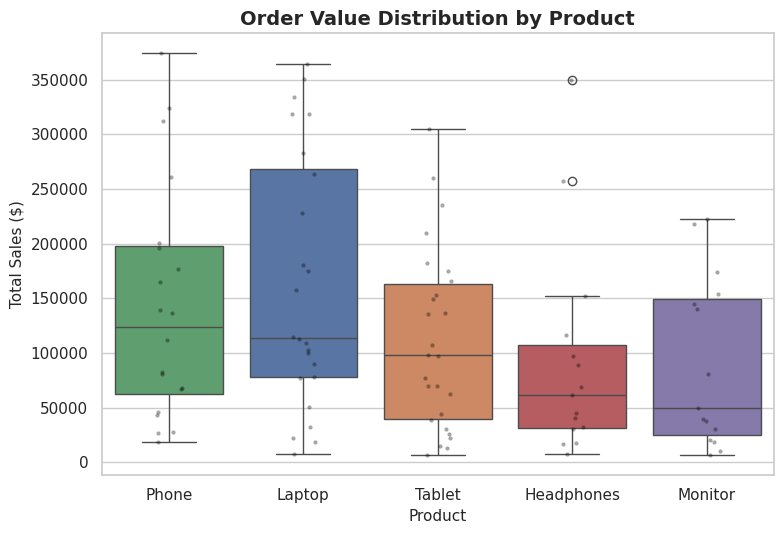

In [4]:
# Box plot: order value distribution by product, with individual points overlaid
fig, ax = plt.subplots(figsize=(8, 5.5))
order = df.groupby('Product')['Total_Sales'].median().sort_values(ascending=False).index
sns.boxplot(x='Product', y='Total_Sales', data=df, order=order,
            hue='Product', palette=PRODUCT_COLORS, legend=False, ax=ax)
sns.stripplot(x='Product', y='Total_Sales', data=df, order=order,
              color='black', alpha=0.35, size=3, jitter=True, ax=ax)
ax.set_title('Order Value Distribution by Product')
ax.set_xlabel('Product'); ax.set_ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('visualizations/01_box_plot_product.png', dpi=150)
plt.show()

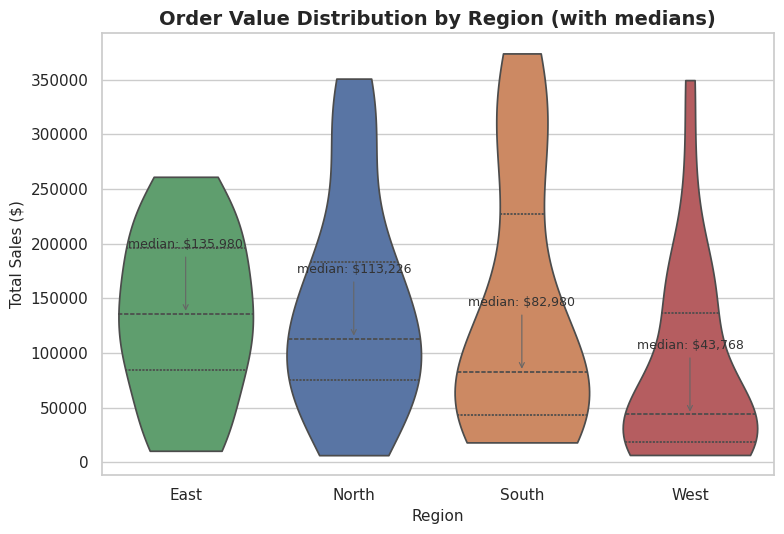

In [5]:
# Violin plot with statistical annotations (median per region)
fig, ax = plt.subplots(figsize=(8, 5.5))
order = df.groupby('Region')['Total_Sales'].median().sort_values(ascending=False).index
sns.violinplot(x='Region', y='Total_Sales', data=df, order=order,
                hue='Region', palette=REGION_COLORS, legend=False,
                inner='quartile', cut=0, ax=ax)
medians = df.groupby('Region')['Total_Sales'].median()
for i, region in enumerate(order):
    ax.annotate(f"median: ${medians[region]:,.0f}",
                xy=(i, medians[region]), xytext=(i, medians[region] + 60000),
                ha='center', fontsize=9, color='#333333',
                arrowprops=dict(arrowstyle='->', color='#666666', lw=0.8))
ax.set_title('Order Value Distribution by Region (with medians)')
ax.set_xlabel('Region'); ax.set_ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('visualizations/02_violin_plot_region.png', dpi=150)
plt.show()

**Reading these two charts:** Laptop and Phone have the highest median
order values and the widest spread, meaning big-ticket outlier orders are
common there. Regionally, the East has the highest median order value, but
the North's violin is widest near the top — a sign North has more large
orders overall even though its typical (median) order is smaller.

## Day 3: Heatmaps & Correlation

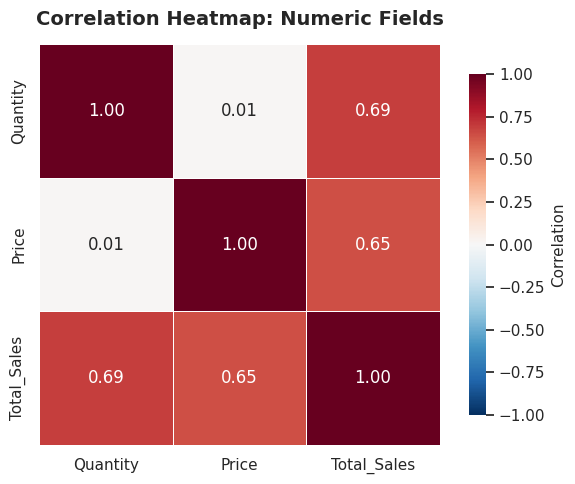

In [6]:
# Correlation heatmap of the numeric fields
fig, ax = plt.subplots(figsize=(6.5, 5))
corr = df[['Quantity', 'Price', 'Total_Sales']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlation', 'shrink': 0.85})
ax.set_title('Correlation Heatmap: Numeric Fields', pad=14)
plt.tight_layout()
plt.savefig('visualizations/03_correlation_heatmap.png', dpi=150)
plt.show()

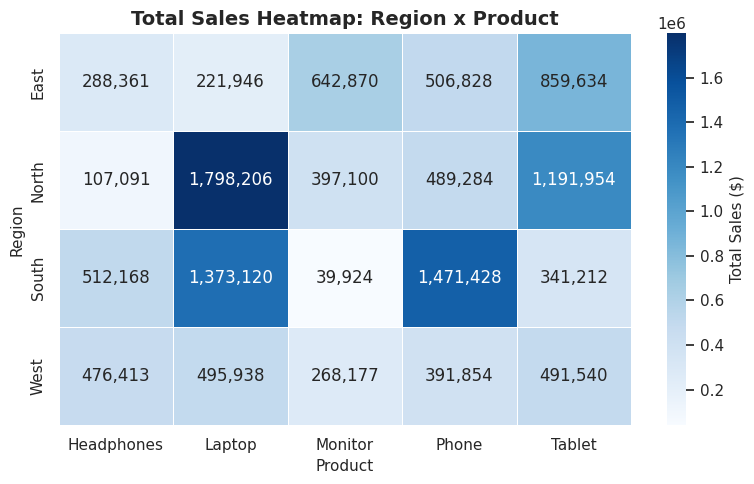

In [7]:
# Custom heatmap: total sales by Region x Product (a pivot table, visualized)
fig, ax = plt.subplots(figsize=(8, 5))
pivot = pd.pivot_table(df, index='Region', columns='Product',
                        values='Total_Sales', aggfunc='sum', fill_value=0)
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='Blues', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Total Sales ($)'})
ax.set_title('Total Sales Heatmap: Region x Product')
plt.tight_layout()
plt.savefig('visualizations/04_region_product_heatmap.png', dpi=150)
plt.show()

**Reading these two charts:** Quantity and Total_Sales are strongly
correlated (0.69), as expected, but Price alone is only moderately
correlated (0.65) — order value is driven by both how many units and how
expensive they are, not price alone. The region x product heatmap shows
this isn't uniform: North's Laptop sales ($1.8M) dominate that cell, while
South does unusually well in Headphones and Phone relative to other
products.

## Day 4: Multi-Plot Dashboard — 2x2 Subplot Grid

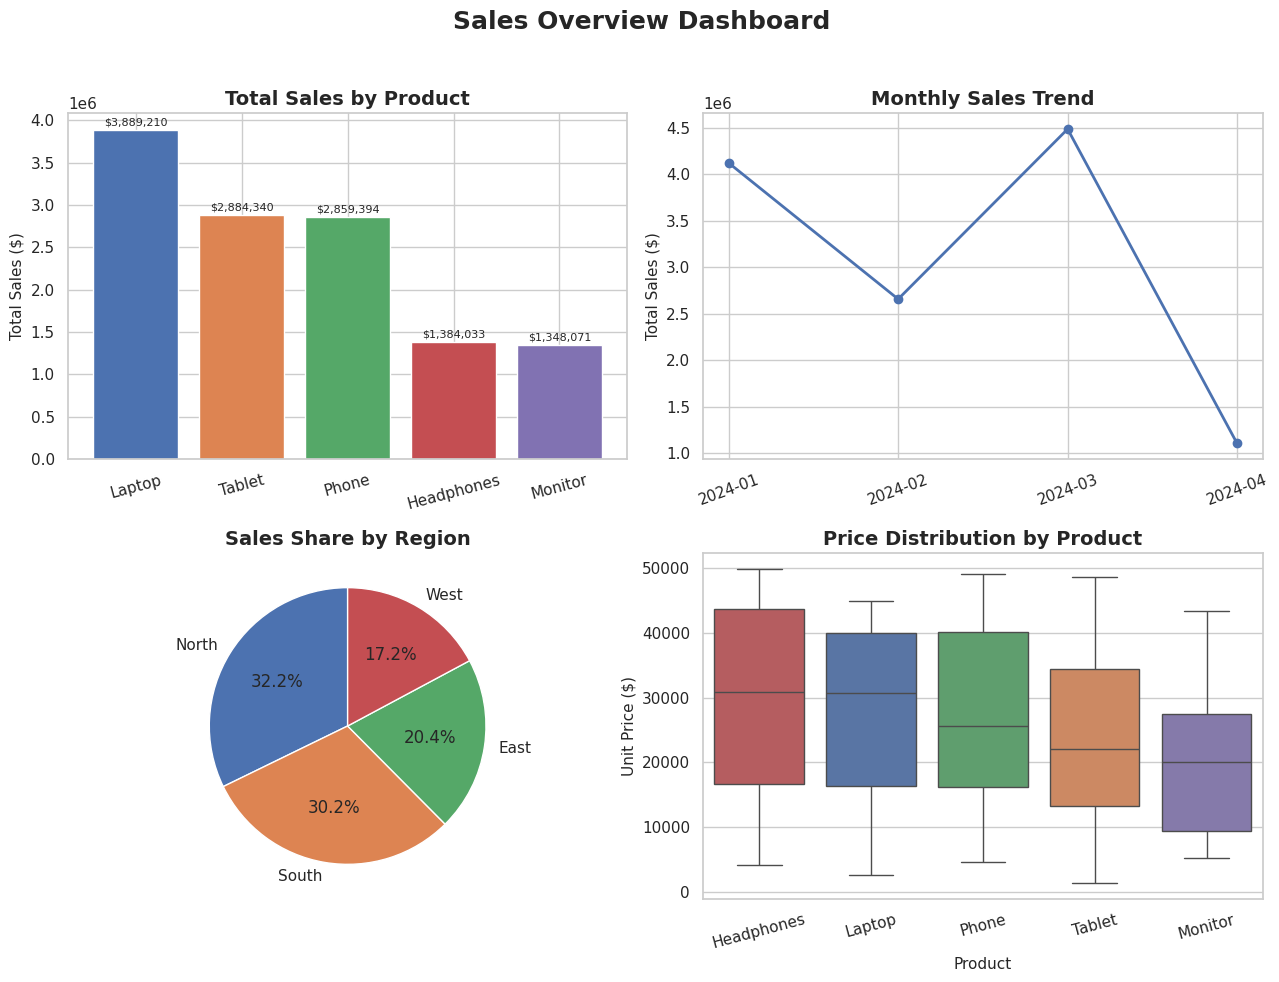

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Sales Overview Dashboard', fontsize=18, fontweight='bold', y=0.98)

product_sales = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False)
bars = axes[0, 0].bar(product_sales.index, product_sales.values,
                       color=[PRODUCT_COLORS[p] for p in product_sales.index])
axes[0, 0].set_title('Total Sales by Product')
axes[0, 0].set_ylabel('Total Sales ($)')
axes[0, 0].bar_label(bars, fmt='${:,.0f}'.format, padding=2, fontsize=8)
axes[0, 0].tick_params(axis='x', rotation=15)

monthly = df.groupby('Month')['Total_Sales'].sum().sort_index()
axes[0, 1].plot(monthly.index.astype(str), monthly.values, marker='o',
                 color='#4C72B0', linewidth=2)
axes[0, 1].set_title('Monthly Sales Trend')
axes[0, 1].set_ylabel('Total Sales ($)')
axes[0, 1].tick_params(axis='x', rotation=20)

region_sales = df.groupby('Region')['Total_Sales'].sum().sort_values(ascending=False)
axes[1, 0].pie(region_sales.values, labels=region_sales.index, autopct='%1.1f%%',
                colors=[REGION_COLORS[r] for r in region_sales.index], startangle=90)
axes[1, 0].set_title('Sales Share by Region')

order = df.groupby('Product')['Price'].median().sort_values(ascending=False).index
sns.boxplot(x='Product', y='Price', data=df, order=order, ax=axes[1, 1],
            hue='Product', palette=PRODUCT_COLORS, legend=False)
axes[1, 1].set_title('Price Distribution by Product')
axes[1, 1].set_ylabel('Unit Price ($)')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('visualizations/05_2x2_subplot_dashboard.png', dpi=150)
plt.show()

## Day 5: Interactive Visualizations with Plotly

Each chart below is built as a plain Python dict that follows the exact
Plotly.js figure schema (`data` / `layout` / `frames`). `plotly_fragment_html()`
renders that dict as a live, interactive chart — using the real `plotly`
package if it's installed, or an equivalent CDN-based HTML/JS fallback if not.
Either way the output is a genuine interactive chart, not a static picture.

**Note:** rendering requires internet access in the viewer's browser (to load
plotly.js from its CDN) — the same requirement as any standard
`fig.write_html(..., include_plotlyjs='cdn')` export.

In [9]:
# Interactive scatter: Quantity vs Price, bubble size = order total, hover for details
traces = []
for region in sorted(df['Region'].unique()):
    sub = df[df['Region'] == region]
    traces.append({
        'type': 'scatter', 'mode': 'markers', 'name': region,
        'x': sub['Quantity'].tolist(), 'y': sub['Price'].tolist(),
        'marker': {
            'size': (sub['Total_Sales'] / sub['Total_Sales'].max() * 40 + 8).tolist(),
            'color': REGION_COLORS[region], 'opacity': 0.75,
            'line': {'width': 1, 'color': 'white'},
        },
        'customdata': list(zip(sub['Product'], sub['Customer_ID'], sub['Total_Sales'])),
        'hovertemplate': (
            '<b>%{customdata[0]}</b><br>Customer: %{customdata[1]}<br>'
            'Quantity: %{x}<br>Unit Price: $%{y:,.0f}<br>'
            'Total Sale: $%{customdata[2]:,.0f}<extra>' + region + '</extra>'
        ),
    })

scatter_fig = {
    'data': traces,
    'layout': {
        'title': {'text': 'Quantity vs. Unit Price (hover for details)'},
        'xaxis': {'title': {'text': 'Quantity'}},
        'yaxis': {'title': {'text': 'Unit Price ($)'}},
        'legend': {'title': {'text': 'Region'}},
        'template': 'plotly_white', 'height': 480,
    },
}
print("Built scatter figure with", len(traces), "traces (one per region).")
display(HTML(plotly_fragment_html(scatter_fig, 'scatter_chart')))

Built scatter figure with 4 traces (one per region).


In [10]:
# Interactive bar chart with a dropdown to switch the metric shown, by Product
by_product = df.groupby('Product')
metrics = {
    'Total Sales ($)': by_product['Total_Sales'].sum(),
    'Average Order Value ($)': by_product['Total_Sales'].mean(),
    'Units Sold': by_product['Quantity'].sum(),
    'Orders Count': by_product['Total_Sales'].count(),
}
order = metrics['Total Sales ($)'].sort_values(ascending=False).index.tolist()
metrics = {k: v.reindex(order) for k, v in metrics.items()}
initial = list(metrics.keys())[0]

trace = {'type': 'bar', 'x': order, 'y': metrics[initial].tolist(),
          'marker': {'color': [PRODUCT_COLORS[p] for p in order]}, 'name': initial}

buttons = [{'label': name, 'method': 'update',
            'args': [{'y': [metrics[name].tolist()]},
                     {'yaxis': {'title': {'text': name}}}]}
           for name in metrics]

dropdown_fig = {
    'data': [trace],
    'layout': {
        'title': {'text': 'Product Performance (use the dropdown to change metric)'},
        'xaxis': {'title': {'text': 'Product'}},
        'yaxis': {'title': {'text': initial}},
        'updatemenus': [{'type': 'dropdown', 'x': 1.0, 'xanchor': 'right',
                          'y': 1.18, 'yanchor': 'top', 'buttons': buttons}],
        'template': 'plotly_white', 'height': 480,
    },
}
print("Built dropdown bar figure with", len(buttons), "metric options.")
display(HTML(plotly_fragment_html(dropdown_fig, 'dropdown_chart')))

Built dropdown bar figure with 4 metric options.


In [11]:
# Animated bar chart "race": cumulative sales by product, month by month
months = sorted(df['Month'].unique())
products = df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False).index.tolist()

cumulative = pd.DataFrame(0.0, index=months, columns=products)
for m in months:
    totals = df[df['Month'] <= m].groupby('Product')['Total_Sales'].sum()
    for p in products:
        cumulative.loc[m, p] = totals.get(p, 0.0)

frames = [{'name': str(m),
           'data': [{'type': 'bar', 'x': products,
                     'y': cumulative.loc[m, products].tolist(),
                     'marker': {'color': [PRODUCT_COLORS[p] for p in products]}}]}
          for m in months]

slider_steps = [{'label': str(m), 'method': 'animate',
                  'args': [[str(m)], {'mode': 'immediate',
                                       'frame': {'duration': 600, 'redraw': True},
                                       'transition': {'duration': 300}}]}
                 for m in months]

race_fig = {
    'data': frames[0]['data'],
    'layout': {
        'title': {'text': 'Cumulative Product Sales by Month (press Play)'},
        'xaxis': {'title': {'text': 'Product'}},
        'yaxis': {'title': {'text': 'Cumulative Total Sales ($)'},
                  'range': [0, cumulative.values.max() * 1.1]},
        'template': 'plotly_white', 'height': 480,
        'updatemenus': [{'type': 'buttons', 'x': 1.0, 'xanchor': 'right',
                          'y': 1.18, 'yanchor': 'top', 'buttons': [
            {'label': 'Play', 'method': 'animate',
             'args': [None, {'fromcurrent': True,
                              'frame': {'duration': 600, 'redraw': True},
                              'transition': {'duration': 300}}]},
            {'label': 'Pause', 'method': 'animate',
             'args': [[None], {'mode': 'immediate', 'frame': {'duration': 0}}]},
        ]}],
        'sliders': [{'active': 0, 'x': 0.1, 'len': 0.85, 'steps': slider_steps}],
    },
    'frames': frames,
}
print("Built animated race figure with", len(frames), "monthly frames.")
display(HTML(plotly_fragment_html(race_fig, 'race_chart')))

Built animated race figure with 4 monthly frames.


## Day 6: Dashboard Integration

`dashboard.py` combines all eight visualizations (5 static + 3 interactive)
into a single `dashboard.html` page with a consistent header, color scheme,
and card-based grid layout. Run `python dashboard.py` to regenerate it, or
open the existing `dashboard.html` directly.

In [12]:
import os
print("Files in visualizations/:")
for f in sorted(os.listdir('visualizations')):
    print(' -', f)
print()
print("Combined dashboard page exists:", os.path.exists('dashboard.html'))

Files in visualizations/:
 - 00_basic_order_counts.png
 - 01_box_plot_product.png
 - 02_violin_plot_region.png
 - 03_correlation_heatmap.png
 - 04_region_product_heatmap.png
 - 05_2x2_subplot_dashboard.png
 - 06_interactive_scatter.html
 - 07_interactive_dropdown_bar.html
 - 08_interactive_animated_race.html

Combined dashboard page exists: True


## Day 7: Dashboard Guide — Interpreting Each Visualization

| # | Chart | Type | What it shows | Key takeaway |
|---|---|---|---|---|
| 1 | Order Value by Product | Box plot | Spread & outliers of order value per product | Laptop & Phone have the widest, highest-value spread |
| 2 | Order Value by Region | Violin plot | Full distribution shape per region, with medians | East has the highest typical order; North has more large orders overall |
| 3 | Correlation Heatmap | Heatmap | Linear relationships between Quantity, Price, Total_Sales | Total_Sales tracks Quantity (0.69) slightly more than Price (0.65) |
| 4 | Region x Product Heatmap | Heatmap | Total sales for every region/product combination | North's Laptop sales dominate a single cell ($1.8M) |
| 5 | Sales Overview | 2x2 subplot (bar, line, pie, box) | Four angles on the data at a glance | One-screen summary for a standup or exec update |
| 6 | Quantity vs. Price | Interactive scatter | Order-level detail with hover tooltips | Spot outlier orders (high quantity AND high price) instantly |
| 7 | Product Performance | Interactive dropdown bar | Same chart, four swappable metrics | Total Sales and Units Sold don't always agree on the "top" product |
| 8 | Cumulative Sales Race | Interactive animation | How product rankings evolve month by month | Laptop pulls ahead early and holds the lead throughout |

**Executive summary:** Laptop and Phone are the revenue anchors; North and
South are the strongest regions but with different product mixes, which
should inform regional stocking. The interactive scatter is the best tool
for spotting individual outlier orders worth a closer look, while the
animated race shows the product ranking has been stable since February —
useful context for demand planning.